In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
# Charger le dataset utilisateur
df = pd.read_csv(r"..\dataset\user_twitter_data.csv")

df.head()

,user_id,screen_name,followers_count,friends_count,statuses_count,favourites_count,listed_count,verified,default_profile,default_profile_image,...,urls_count,mentions_count,tweet_length,is_retweet,is_quote,lang,n_tweets,followers_friends_ratio,activity_ratio,visibility_score
0,418,dens,87897.333333,2487.833333,66634.166667,13506.0,4535.5,1,0,0,...,0.5,0.666667,113.333333,0.5,0.5,en,6,35.316681,0.758082,133252.333333
1,730,crutis,621.000000,191.000000,12159.000000,3164.0,20.0,0,0,0,...,0.0,1.000000,139.000000,1.0,1.0,en,1,3.234375,19.548232,821.000000
2,761,RodBegbie,4562.000000,483.000000,29724.000000,46254.0,188.0,0,0,0,...,1.0,0.000000,31.000000,0.0,1.0,en,1,9.425620,6.514135,6442.000000
3,885,Ross,21491.000000,1099.000000,13879.000000,6091.0,1883.0,1,0,0,...,0.0,0.000000,88.000000,0.0,0.0,en,1,19.537273,0.645775,40321.000000
4,922,Holger,4399.000000,934.000000,11717.000000,12046.0,268.0,0,0,0,...,0.0,1.000000,140.000000,0.0,0.0,en,1,4.704813,2.662955,7079.000000


In [10]:
# Variables numériques utilisées pour PCA

features = [
    "followers_count",
    "friends_count",
    "statuses_count",
    "favourites_count",
    "listed_count",
    "retweet_count",
    "favorite_count",
    "reply_count",
    "quote_count",
    "hashtags_count",
    "urls_count",
    "mentions_count",
    "tweet_length",
    "is_retweet",
    "is_quote",
    "n_tweets",
    "followers_friends_ratio",
    "activity_ratio",
    "visibility_score"
]

X = df[features]

X.head()

,followers_count,friends_count,statuses_count,favourites_count,listed_count,retweet_count,favorite_count,reply_count,quote_count,hashtags_count,urls_count,mentions_count,tweet_length,is_retweet,is_quote,n_tweets,followers_friends_ratio,activity_ratio,visibility_score
0,87897.333333,2487.833333,66634.166667,13506.0,4535.5,0.0,0.0,0.0,0.0,1.0,0.5,0.666667,113.333333,0.5,0.5,6,35.316681,0.758082,133252.333333
1,621.000000,191.000000,12159.000000,3164.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,139.000000,1.0,1.0,1,3.234375,19.548232,821.000000
2,4562.000000,483.000000,29724.000000,46254.0,188.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,31.000000,0.0,1.0,1,9.425620,6.514135,6442.000000
3,21491.000000,1099.000000,13879.000000,6091.0,1883.0,0.0,0.0,0.0,0.0,1.0,0.0,0.000000,88.000000,0.0,0.0,1,19.537273,0.645775,40321.000000
4,4399.000000,934.000000,11717.000000,12046.0,268.0,0.0,0.0,0.0,0.0,3.0,0.0,1.000000,140.000000,0.0,0.0,1,4.704813,2.662955,7079.000000


In [11]:
# Standardisation des données

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 7.11073526e-01,  3.30972533e-01,  1.20934874e+00,
         2.15689038e-01,  1.13483347e+01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -3.44737121e-01,  5.24042156e-01, -3.51604420e-01,
         1.71051314e-01, -5.07657185e-01,  8.24981785e-01,
         3.79432374e-01, -3.08306304e-03, -8.58321077e-02,
         1.06584387e+00],
       [-2.51394889e-02, -1.38983877e-01, -1.36284213e-01,
        -2.53675873e-01, -1.10557726e-02,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -1.05105068e+00, -6.59431160e-01,  1.35467984e-01,
         9.86488423e-01,  6.64702814e-01,  2.18000156e+00,
        -1.59390435e-01, -5.95728130e-03, -4.64429903e-02,
        -2.49081989e-02],
       [ 8.10452336e-03, -7.92375861e-02,  2.97602350e-01,
         1.70193562e+00,  4.11572420e-01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -1.05105068e+00,  1.70751547e+00, -1.32574923e+00,
    

In [12]:
# Réduction de dimension avec PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

print("Shape PCA :", pca_result.shape)

Shape PCA : (1843439, 2)


In [13]:
# Création du DataFrame PCA

pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2"]
)

pca_df["user_id"] = df["user_id"]
pca_df["screen_name"] = df["screen_name"]

pca_df.head()

,PC1,PC2,user_id,screen_name
0,6.952529,0.455064,418,dens
1,-0.084913,0.232943,730,crutis
2,0.627354,4.270116,761,RodBegbie
3,2.680392,0.843353,885,Ross
4,0.300918,-0.645254,922,Holger


In [14]:
# Variance expliquée

print("Variance expliquée :", pca.explained_variance_ratio_)

print(
    "Variance totale expliquée :",
    sum(pca.explained_variance_ratio_)
)

Variance expliquée : [0.18426847 0.16933215]
Variance totale expliquée : 0.3536006204723434


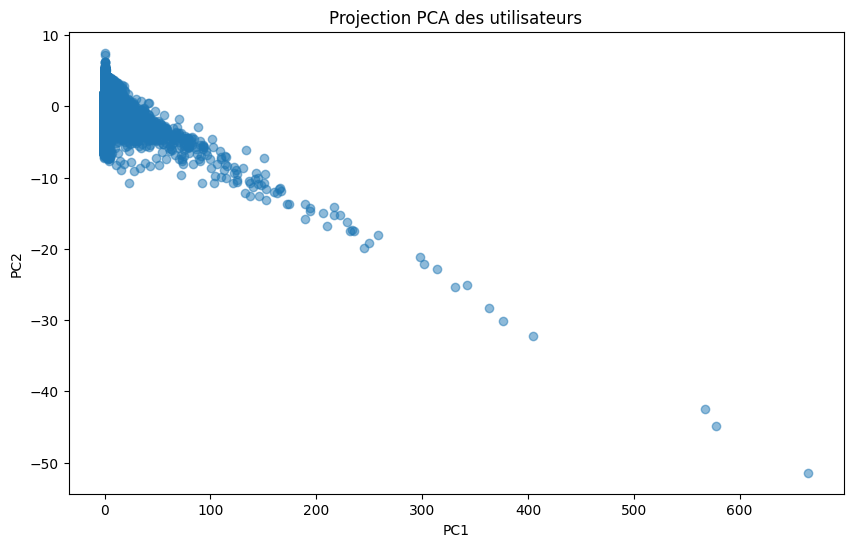

In [15]:
# Visualisation PCA

plt.figure(figsize=(10, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.5
)

plt.title("Projection PCA des utilisateurs")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [17]:
# Sauvegarder les données PCA

# Le notebook se trouve dans Traitement_des_donnees,
# donc on remonte d'un niveau pour accéder au dossier dataset.

pca_df.to_csv(
    "../dataset/data_with_pca.csv",
    index=False,
    encoding="utf-8"
)

print("Fichier PCA sauvegardé dans le dossier dataset.")

Fichier PCA sauvegardé dans le dossier dataset.


In [19]:
# Variance expliquée par PCA

print("Variance expliquée :", pca.explained_variance_ratio_)

print(
    "Variance totale expliquée :",
    sum(pca.explained_variance_ratio_)
)

Variance expliquée : [0.18426847 0.16933215]
Variance totale expliquée : 0.3536006204723434
